<a href="https://colab.research.google.com/github/srushtinagaraju/Machine_Learning_1BM24CS424/blob/main/1BM24CS424_Lab-4%20Logistic_Regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


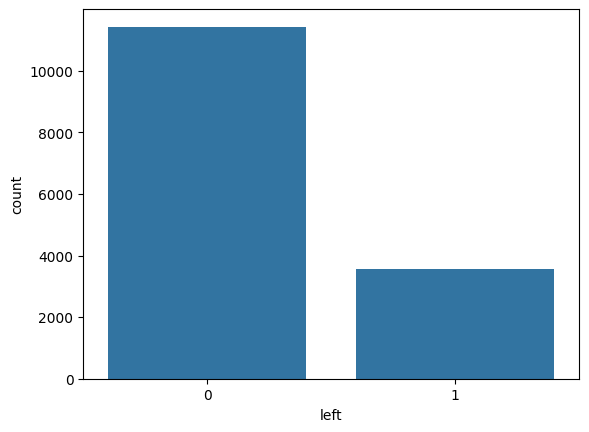

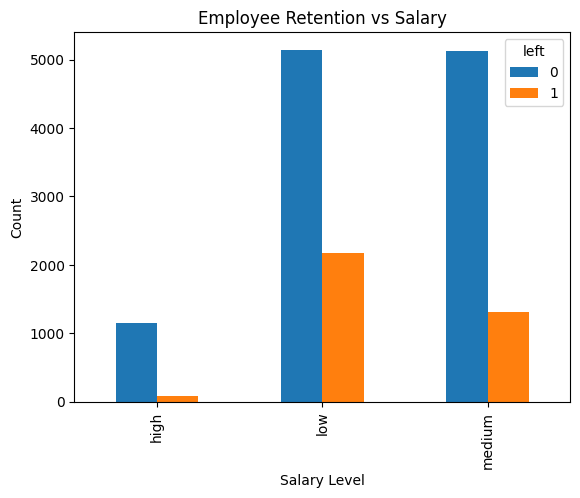

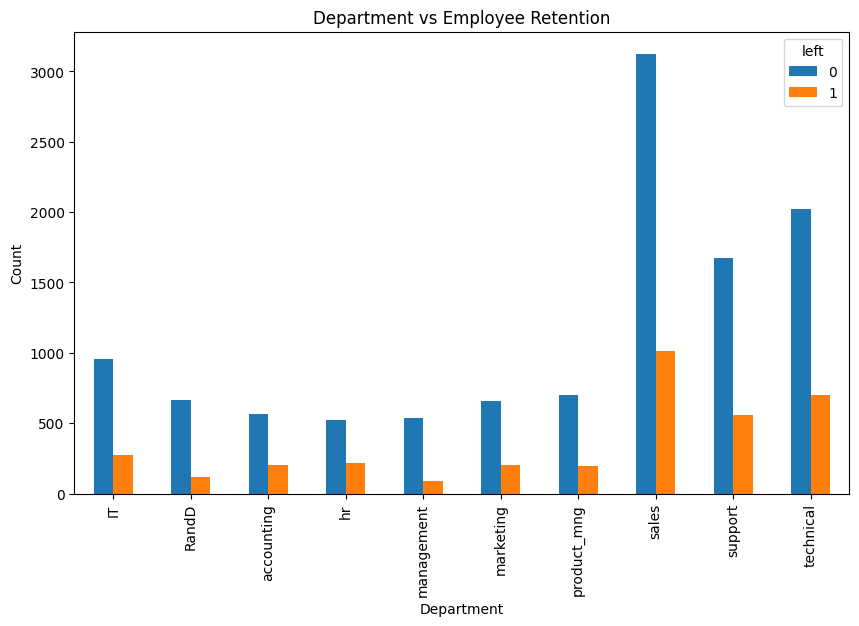

Accuracy: 0.765

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      2294
           1       0.50      0.23      0.32       706

    accuracy                           0.77      3000
   macro avg       0.65      0.58      0.59      3000
weighted avg       0.73      0.77      0.73      3000


Confusion Matrix:
[[2132  162]
 [ 543  163]]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("HR_comma_sep.csv")
df.head()
df.info()
df.describe()

df['left'].value_counts()
sns.countplot(x='left', data=df)
plt.show()


pd.crosstab(df.salary, df.left).plot(kind='bar')
plt.title("Employee Retention vs Salary")
plt.xlabel("Salary Level")
plt.ylabel("Count")
plt.show()

pd.crosstab(df.Department, df.left).plot(kind='bar', figsize=(10,6))
plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

X = df[['satisfaction_level',
        'average_montly_hours',
        'promotion_last_5years']]
X = pd.concat([X, pd.get_dummies(df['salary'], drop_first=True)], axis=1)
X = pd.concat([X, pd.get_dummies(df['Department'], drop_first=True)], axis=1)
y = df['left']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.9523809523809523


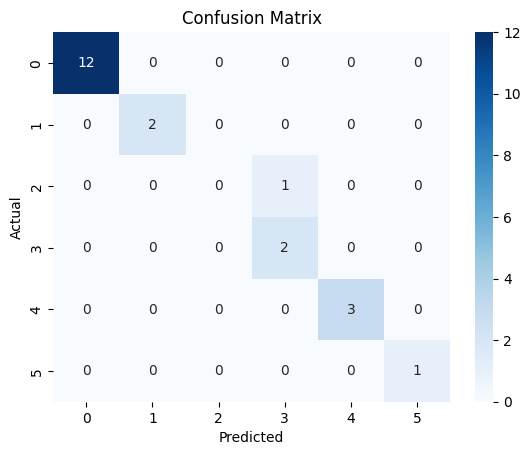

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

zoo = pd.read_csv("zoo-data.csv")
zoo = zoo.drop("animal_name", axis=1)

X = zoo.drop("class_type", axis=1)
y = zoo["class_type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
